# 한 픽셀만 가지고 분류하는 것이 가능성 있는지 검증

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch.optim as optim
import rasterio
import copy
import torch.nn.init as init

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### train, eval 함수 정의 (Naive ver과 동일)

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = model.state_dict()  # 초기 모델 가중치 저장
    no_improve_count = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)  # 배치별 loss * 개수로 전체 손실 계산
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)  # 전체 샘플 수로 나눔
        train_accuracy = 100 * correct / total
        train_losses.append(train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = 100 * val_correct / val_total
        val_losses.append(val_loss)

        print(f"\nEpoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%\n")

        # Early Stopping & Model Saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            print("Early stopping triggered. Training stopped.")
            break
    
    return best_model_state, train_losses, val_losses


In [4]:
target_name_mapping = {
    0: "Non-Forest", #비산림
    1: "Pine", #소나무
    2: "Nut Pine", #잣나무
    3: "Larch", #낙엽송
    4: "Pitch Pine", #리기다 소나무
    5: "Oak", #상수리나무
    6: "Mongolian Oak", #신갈나무
    7: "Oriental Oak" #굴참나무
}

def evaluate_model_with_cm(model, val_loader, num_classes=8, target_name_mapping=target_name_mapping):
    model.eval()
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation Progress"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())  
            all_predictions.extend(predicted.cpu().numpy())  

    # 모든 클래스 목록 (0 ~ num_classes-1)
    full_class_labels = np.arange(num_classes)

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_predictions, labels=full_class_labels)

    # Confusion Matrix 시각화
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_name_mapping.values(), yticklabels=target_name_mapping.values())
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    target_names = list(target_name_mapping.values())
    report = classification_report(all_labels, all_predictions, labels=full_class_labels, target_names=target_names, digits=3)

    print("Classification Report:")
    print(report)


### Dataset 클래스 정의   
x_pos, y_pos의 데이터만 가져오도록 함.

In [36]:
class TiffDataset(Dataset):
    def __init__(self, large_tif_dir, file_list, label_file, patch_size=1, box_filter_fn=None, transform=None):
        """
        Args:
            large_tif_dir (str): 여러 개의 큰 TIFF 파일이 저장된 디렉토리 경로.
            file_list (list of str): 처리할 원천 데이터 파일명 리스트.
            label_file (str): 라벨 정보를 담은 CSV 파일 경로 ("file", "x_pos", "y_pos", "label" 열 포함).
            patch_size (int): 슬라이싱할 이미지의 크기 (항상 홀수여야 함).
            box_filter_fn (callable, optional): 박스 번호 필터링 함수.
            transform (callable, optional): 이미지 전처리에 사용할 함수.
        """
        if patch_size % 2 == 0:
            raise ValueError("patch_size는 홀수여야 합니다.")

        self.large_tif_dir = large_tif_dir
        self.file_list = set(file_list)
        self.label_df = pd.read_csv(label_file)

        # 박스 필터 함수 설정 (기본값: 모든 박스 사용)
        self.box_filter_fn = box_filter_fn or (lambda box_number: True)

        # 파일명 필터링: file_list에 있는 파일만 유지
        self.label_df = self.label_df[self.label_df['file'].isin(self.file_list)].reset_index(drop=True)

        # 박스 번호 필터링
        self.label_df = self.label_df[self.label_df['box_number'].apply(self.box_filter_fn)].reset_index(drop=True)

        self.patch_size = patch_size
        self.half_size = patch_size // 2  # 패치의 반 크기
        self.transform = transform

        # 각 파일명을 키로 하고 이미지를 값으로 가지는 딕셔너리
        self.image_cache = {}

    def _load_image(self, file_name):
        """파일 이름에 해당하는 이미지를 로드하여 캐시에 저장."""
        if file_name not in self.image_cache:
            file_path = os.path.join(self.large_tif_dir, file_name)
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"Image file '{file_path}' not found.")
            self.image_cache[file_name] = tiff.imread(file_path)
        return self.image_cache[file_name]

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        # 현재 인덱스에 해당하는 데이터 가져오기
        row = self.label_df.iloc[idx]
        file_name = row["file"]
        x, y = row["x_pos"], row["y_pos"]
        label = row["label"]

        # 이미지 로드
        image = self._load_image(file_name)
        image_height, image_width = image.shape[:2]

        # 중심 좌표 기준으로 패치의 좌상단 좌표 계산
        x_start = x - self.half_size
        y_start = y - self.half_size
        x_end = x + self.half_size + 1  # 슬라이싱할 범위는 [start:end]
        y_end = y + self.half_size + 1

        # 범위 검사
        if x_start < 0 or y_start < 0 or x_end > image_width or y_end > image_height:
            raise ValueError(f"Patch centered at (x={x}, y={y}) exceeds bounds of image '{file_name}'.")

        # 이미지 슬라이싱
        patch = image[y_start:y_end, x_start:x_end]

        # 전처리 적용
        if self.transform:
            patch = self.transform(patch)

        return patch, label


### 테스트지역 선별 (Naive ver과 동의)

In [37]:
# 테스트 필터 정의
test_filter = lambda box_number: (box_number % 9 == 0 or box_number % 9 == 5)

### 데이터 전처리 방법 설정_flatten

In [38]:
# 이미지 전처리 (Naive)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.float()),   # uint16 → float 변환
    transforms.Lambda(lambda x: x.view(-1)),    # flatten: (C, H, W) → (C*H*W,)
])

### DNN사용

In [39]:
# Residual MLP Block
class BasicMLPBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.1):
        """
        동일 차원의 두 개 Linear layer를 쌓고, 중간에 BatchNorm, ReLU, Dropout를 적용합니다.
        입력과 출력 차원이 같으므로 residual connection을 사용할 수 있습니다.
        """
        super(BasicMLPBlock, self).__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.activation = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        identity = x  # residual
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.dropout(out)
        out += identity
        out = self.activation(out)
        return out

# 전체 모델 정의: 충분한 폭(예, 256)과 여러 블록을 반복 사용합니다.
class DNNClassifier(nn.Module):
    def __init__(self, num_classes=8, input_dim=48, width=256, num_blocks=6, dropout_rate=0.1):
        """
        Args:
            num_classes (int): 분류할 클래스 수.
            input_dim (int): 입력 벡터 차원 (여기서는 48).
            width (int): 내부 hidden dimension.
            num_blocks (int): BasicMLPBlock을 몇 번 반복할지.
            dropout_rate (float): 드롭아웃 비율.
        """
        super(DNNClassifier, self).__init__()
        # 입력층: 48 -> width
        self.initial_fc = nn.Linear(input_dim, width)
        self.initial_bn = nn.BatchNorm1d(width)
        self.activation = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout_rate)
        
        # 여러 MLP residual block 쌓기
        blocks = []
        for _ in range(num_blocks):
            blocks.append(BasicMLPBlock(width, dropout_rate=dropout_rate))
        self.blocks = nn.Sequential(*blocks)
        
        # 분류 head
        self.head = nn.Linear(width, num_classes)
        
    def forward(self, x):
        # x: (batch_size, input_dim)
        x = self.initial_fc(x)
        x = self.initial_bn(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.blocks(x)
        logits = self.head(x)
        return logits

### 초기화 함수

In [40]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        # ReLU를 사용할 경우 Kaiming Normal 초기화
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm1d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

## B, G, R, NIR 사용

In [42]:
train_dataset = TiffDataset(
    large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive",
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = lambda box_number: not test_filter(box_number),
    transform=transform
)

val_dataset = TiffDataset(
    large_tif_dir = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\원천 데이터\naive",
    file_list = ["jiri_1.tif", "jiri_2.tif", "sobaek.tif"], #전체 지역을 모두 사용한다.
    label_file = r"C:\Users\taebin\Desktop\my_study\capstone_design\data3\라벨링 데이터\label_mapping_sampled.csv",
    box_filter_fn = test_filter,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [43]:
model = DNNClassifier(num_classes=8, input_dim=48, width=256, num_blocks=6, dropout_rate=0.1)
model.apply(init_weights)   
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 모델 학습

In [30]:
best_model_state, train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, patience=100)
model.load_state_dict(best_model_state)

Epoch 1/30 - Validation: 100%|██████████| 1169/1169 [00:13<00:00, 88.99it/s] 



Epoch [1/30], Train Loss: 0.6638, Train Accuracy: 76.10%, Val Loss: 0.6015, Val Accuracy: 78.19%



Epoch 2/30 - Validation: 100%|██████████| 1169/1169 [00:09<00:00, 119.07it/s]



Epoch [2/30], Train Loss: 0.4912, Train Accuracy: 82.02%, Val Loss: 0.5569, Val Accuracy: 80.69%



Epoch 3/30 - Validation: 100%|██████████| 1169/1169 [00:10<00:00, 114.23it/s]


...

Epoch 29/30 - Validation: 100%|██████████| 1169/1169 [00:10<00:00, 115.05it/s]



Epoch [29/30], Train Loss: 0.2556, Train Accuracy: 90.64%, Val Loss: 0.6058, Val Accuracy: 81.57%



Epoch 30/30 - Validation: 100%|██████████| 1169/1169 [00:09<00:00, 123.61it/s]


Epoch [30/30], Train Loss: 0.2540, Train Accuracy: 90.77%, Val Loss: 0.6249, Val Accuracy: 81.69%



<All keys matched successfully>

In [31]:
torch.save(best_model_state, "one_px_30.pth")

### 모델 테스트

train data

Evaluation Progress: 100%|██████████| 3733/3733 [00:33<00:00, 110.57it/s]


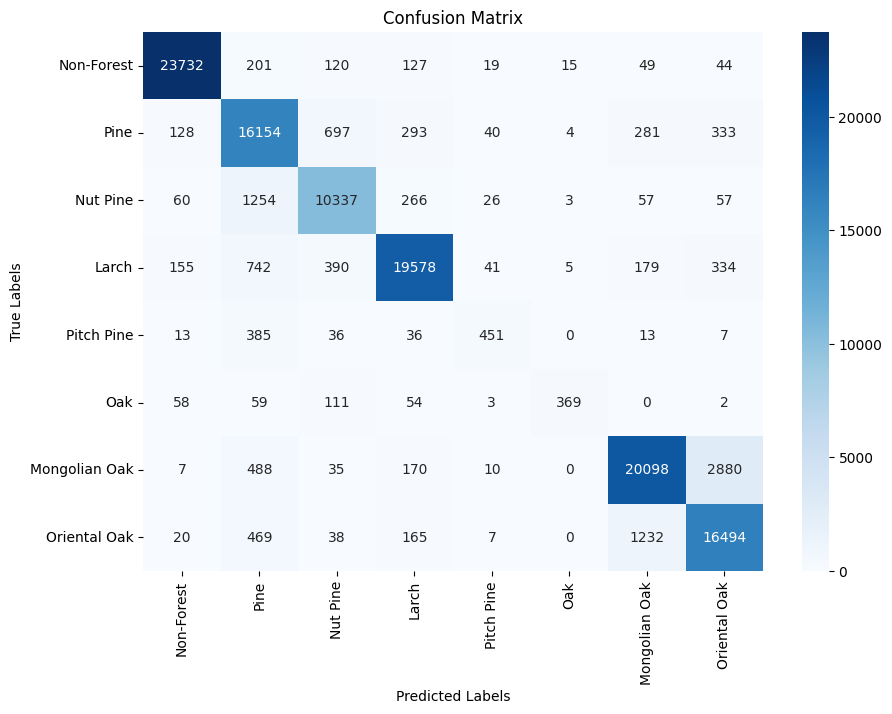

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.982     0.976     0.979     24307
         Pine      0.818     0.901     0.857     17930
     Nut Pine      0.879     0.857     0.868     12060
        Larch      0.946     0.914     0.930     21424
   Pitch Pine      0.755     0.479     0.586       941
          Oak      0.932     0.562     0.702       656
Mongolian Oak      0.917     0.848     0.882     23688
 Oriental Oak      0.819     0.895     0.855     18425

     accuracy                          0.898    119431
    macro avg      0.881     0.804     0.832    119431
 weighted avg      0.900     0.898     0.898    119431



In [34]:
evaluate_model_with_cm(model, train_loader, num_classes=8)

validation data

Evaluation Progress: 100%|██████████| 1169/1169 [00:10<00:00, 111.06it/s]


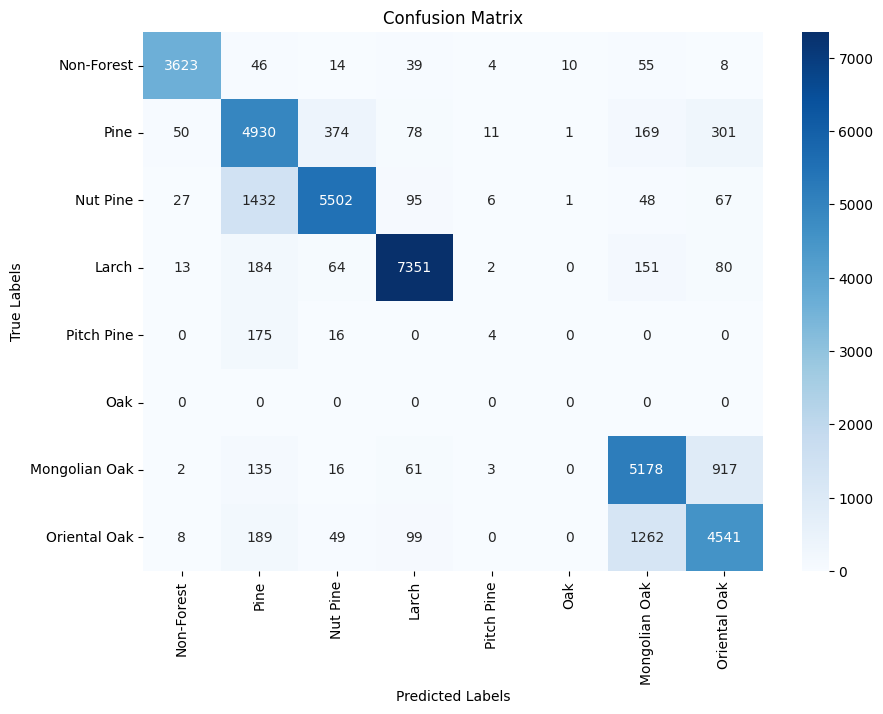

Classification Report:
               precision    recall  f1-score   support

   Non-Forest      0.973     0.954     0.963      3799
         Pine      0.695     0.834     0.758      5914
     Nut Pine      0.912     0.767     0.833      7178
        Larch      0.952     0.937     0.944      7845
   Pitch Pine      0.133     0.021     0.036       195
          Oak      0.000     0.000     0.000         0
Mongolian Oak      0.754     0.820     0.786      6312
 Oriental Oak      0.768     0.739     0.753      6148

     accuracy                          0.833     37391
    macro avg      0.648     0.634     0.634     37391
 weighted avg      0.838     0.833     0.832     37391



c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\taebin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
evaluate_model_with_cm(model, val_loader, num_classes=8)

### 어느정도 높은 성능을 보인다. -> Texture가 그렇게 중요하지 않음을 알 수 있다.